In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [3]:
FOLDERS = {
    "data/full-drumstick/test2-0": "No fracture hammer 1",
    "data/full-drumstick/test2-100": "100% Fracture hammer 1",
    "data/full-drumstick/test3-0": "No fracture hammer 2",
    "data/full-drumstick/test3-100": "100% Fracture hammer 2",
    "data/full-drumstick/test4-0": "No fracture hammer 3",
    "data/full-drumstick/test4-100": "100% Fracture hammer 3",
    "data/full-drumstick/test5-0": "No fracture hammer 4",
    "data/full-drumstick/test5-100": "100% Fracture hammer 4"
}

group_data = {}

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    if not csv_files:
        print(f"No CSV files found in {folder}")
        continue

    impedances = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        # Skip incomplete sweeps
        if len(df) != len(frequency):
            print(
                f"Skipping {csv_file.name}: "
                f"{len(df)} rows instead of {len(frequency)}"
            )
            continue

        impedances.append(df["impedance"].values)

    if len(impedances) == 0:
        print(f"No valid files found in {folder}")
        continue

    impedances = np.vstack(impedances)

    group_data[label] = {
        "frequency": frequency,
        "mean": np.mean(impedances, axis=0),
        "std": np.std(impedances, axis=0),
        "raw": impedances,
        "n": len(impedances)
    }

    print(f"{label}: {len(impedances)} files loaded")

No fracture hammer 1: 6 files loaded
100% Fracture hammer 1: 15 files loaded
No fracture hammer 2: 11 files loaded
100% Fracture hammer 2: 14 files loaded
No fracture hammer 3: 7 files loaded
100% Fracture hammer 3: 7 files loaded
No fracture hammer 4: 9 files loaded
100% Fracture hammer 4: 9 files loaded


# Create x, and y and split into test and train

In [4]:
X = []
y = []

for group_name, data in group_data.items():

    for sweep in data["raw"]:
        X.append(sweep)
        y.append(group_name)

X = np.array(X)

X = StandardScaler().fit_transform(X)

df = pd.DataFrame(X, columns=frequency)
df["broken"] = ["100% Fracture" in label for label in y]

In [5]:
df

,10000.0,11800.0,13600.0,15400.0,17200.0,19000.0,20800.0,22600.0,24400.0,26200.0,...,85600.0,87400.0,89200.0,91000.0,92800.0,94600.0,96400.0,98200.0,100000.0,broken
0,-0.308430,-0.316214,-0.434700,-0.476483,-0.502676,-0.493093,-0.512157,-0.501684,-0.505930,-0.511849,...,-0.520557,-0.518348,-0.519776,-0.529611,-0.538360,-0.532079,-0.527661,-0.527597,-0.525156,False
1,-0.313993,-0.315023,-0.415227,-0.495671,-0.509460,-0.502557,-0.517921,-0.515810,-0.507350,-0.524807,...,-0.531837,-0.533364,-0.525452,-0.541403,-0.555572,-0.544572,-0.541804,-0.537668,-0.536300,False
2,-0.367490,-0.304546,-0.483339,-0.497793,-0.508369,-0.522456,-0.531912,-0.525228,-0.513640,-0.533515,...,-0.544023,-0.544714,-0.536667,-0.551044,-0.564528,-0.556077,-0.555098,-0.550166,-0.553230,False
3,-0.329887,-0.319865,-0.450577,-0.511077,-0.529480,-0.520903,-0.544424,-0.534341,-0.533878,-0.539810,...,-0.561709,-0.565721,-0.563942,-0.571367,-0.583770,-0.574852,-0.574898,-0.570378,-0.570946,False
4,-0.334800,-0.356378,-0.464085,-0.510155,-0.558751,-0.536337,-0.550681,-0.550796,-0.548943,-0.557121,...,-0.579117,-0.583768,-0.579726,-0.589054,-0.599093,-0.591015,-0.594273,-0.587448,-0.588019,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,1.182121,1.169736,1.147834,1.147360,1.167055,1.175662,1.161047,1.153633,1.165870,1.162819,...,1.197823,1.212740,1.204452,1.221968,1.218711,1.219414,1.215553,1.217852,1.222664,True
74,1.135595,1.094052,1.150465,1.117932,1.155148,1.165615,1.164692,1.149886,1.165261,1.165862,...,1.215162,1.215208,1.228266,1.224257,1.220670,1.222943,1.225382,1.223495,1.220950,True
75,1.147660,1.136637,1.133141,1.148144,1.144236,1.168576,1.186959,1.157936,1.172768,1.165862,...,1.173174,1.227685,1.216290,1.209552,1.219901,1.225131,1.229625,1.219852,1.228308,True
76,1.198773,1.163466,1.213094,1.154556,1.162928,1.184204,1.175973,1.175758,1.167087,1.169691,...,1.223030,1.221834,1.230689,1.231054,1.224589,1.230001,1.232524,1.239636,1.229808,True


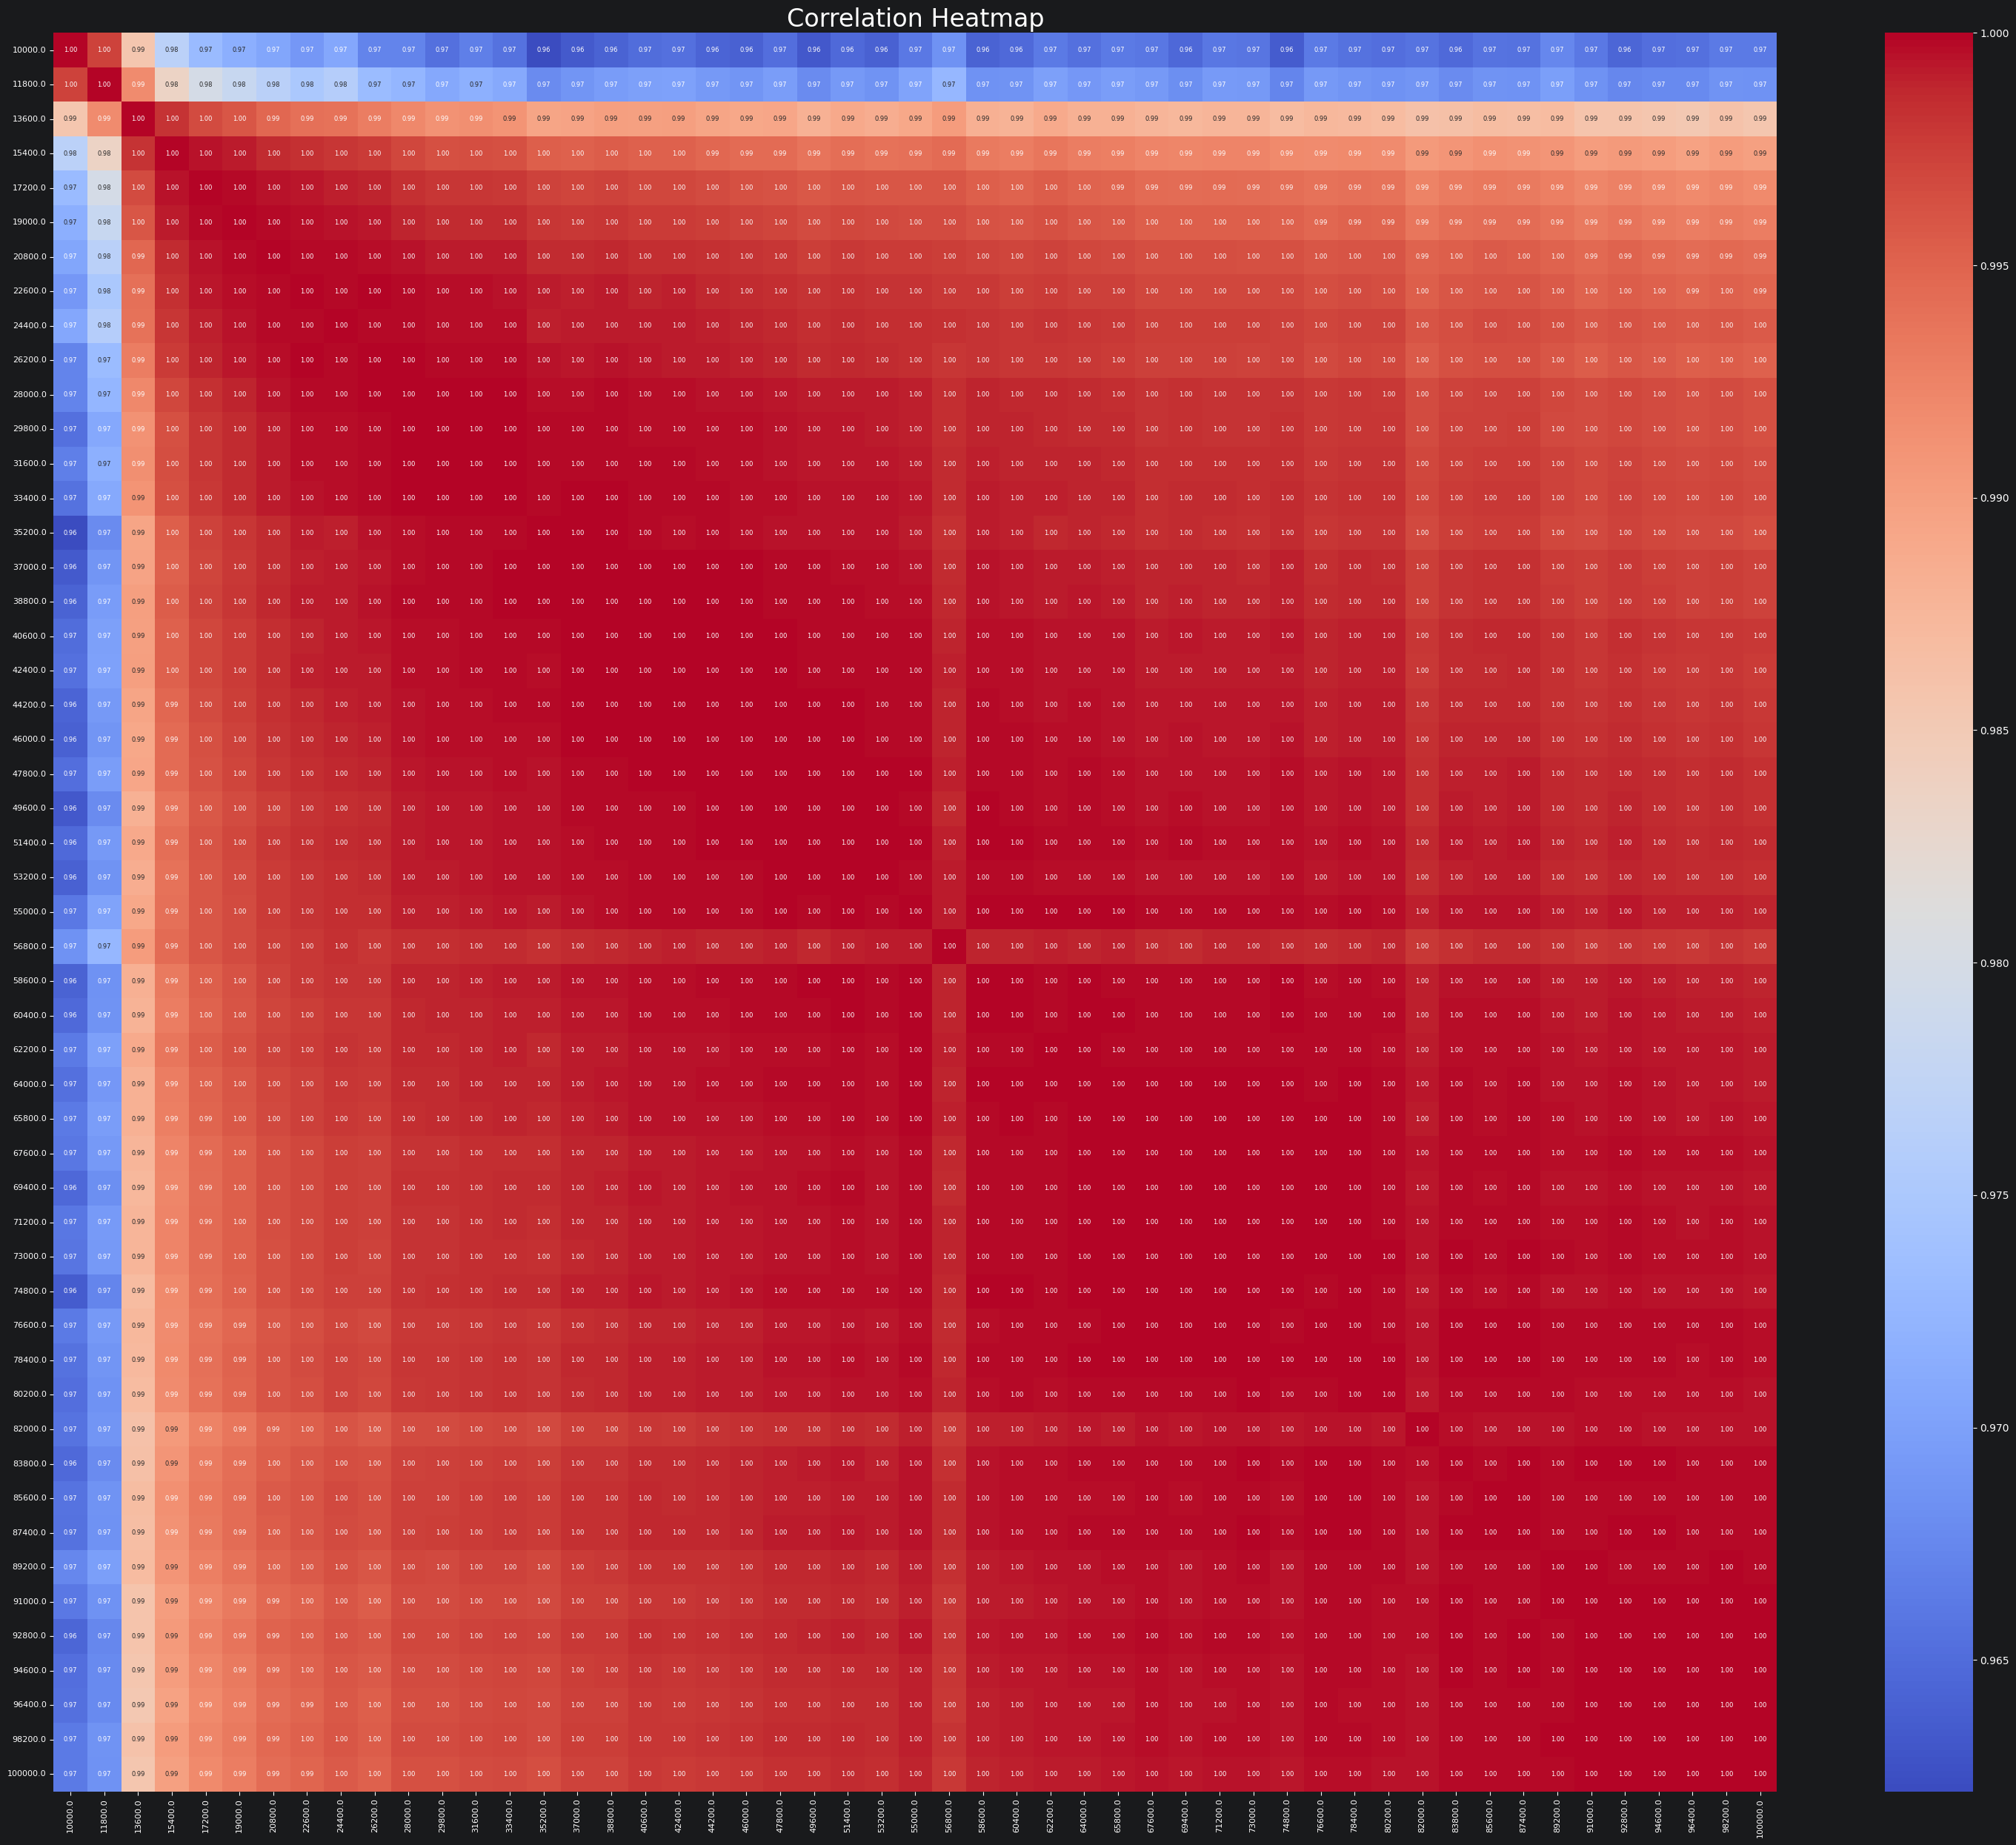

In [6]:
correlation_matrix = df.drop(columns=["broken"]).corr()

plt.figure(figsize=(30, 25))  # Much larger figure

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 6}  # Smaller text
)

plt.title("Correlation Heatmap", fontsize=24)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
# Features (everything except target)
X_ml = df.drop(columns=["broken"])

# Target
y_ml = df["broken"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.2,
    random_state=42,
    stratify=y_ml
)

In [8]:
# Train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [9]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[7 0]
 [0 9]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00         7
        True       1.00      1.00      1.00         9

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [10]:
print(df.shape)
print(df.head())

(78, 52)
    10000.0   11800.0   13600.0   15400.0   17200.0   19000.0   20800.0  \
0 -0.308430 -0.316214 -0.434700 -0.476483 -0.502676 -0.493093 -0.512157   
1 -0.313993 -0.315023 -0.415227 -0.495671 -0.509460 -0.502557 -0.517921   
2 -0.367490 -0.304546 -0.483339 -0.497793 -0.508369 -0.522456 -0.531912   
3 -0.329887 -0.319865 -0.450577 -0.511077 -0.529480 -0.520903 -0.544424   
4 -0.334800 -0.356378 -0.464085 -0.510155 -0.558751 -0.536337 -0.550681   

    22600.0   24400.0   26200.0  ...   85600.0   87400.0   89200.0   91000.0  \
0 -0.501684 -0.505930 -0.511849  ... -0.520557 -0.518348 -0.519776 -0.529611   
1 -0.515810 -0.507350 -0.524807  ... -0.531837 -0.533364 -0.525452 -0.541403   
2 -0.525228 -0.513640 -0.533515  ... -0.544023 -0.544714 -0.536667 -0.551044   
3 -0.534341 -0.533878 -0.539810  ... -0.561709 -0.565721 -0.563942 -0.571367   
4 -0.550796 -0.548943 -0.557121  ... -0.579117 -0.583768 -0.579726 -0.589054   

    92800.0   94600.0   96400.0   98200.0  100000.0  broken

In [11]:
model = Pipeline([
    ("pca", PCA(n_components=0.95)),  # keep 95% variance
    ("classifier", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_ml,
    y_ml,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

Fold accuracies: [0.4375 0.5625 0.6875 0.6    0.6   ]
Mean accuracy: 0.5775
Std: 0.08116341540373964


In [13]:
from sklearn.svm import SVC

model_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf"))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model_svc,
    X_ml,
    y_ml,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())

Fold accuracies: [0.6875     0.5625     0.625      0.73333333 0.86666667]
Mean accuracy: 0.6950000000000001
Std: 0.1033937995132096
